In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

print(df.shape)
print(df.columns.tolist())

(50000, 40)
['customer_id', 'as_of_date', 'region_name', 'age', 'age_band', 'marital_status', 'customer_tenure_months', 'multi_policy_flag', 'num_policies', 'policy_type', 'renewal_month', 'current_premium', 'premium_last_year', 'premium_change_pct', 'num_price_increases_last_3y', 'coverage_amount', 'premium_to_coverage_ratio', 'payment_frequency', 'autopay_enabled', 'late_payment_count_12m', 'missed_payment_flag', 'payment_method_change_flag', 'num_claims_12m', 'num_approved_claims_12m', 'num_rejected_claims_12m', 'num_pending_claims_12m', 'avg_claim_amount', 'total_claim_amount_12m', 'total_payout_amount_12m', 'payout_ratio_12m', 'avg_settlement_time_days', 'days_since_last_claim', 'num_contacts_12m', 'complaint_flag', 'complaint_resolution_days', 'quote_requested_flag', 'coverage_downgrade_flag', 'churn_flag', 'churn_type', 'churn_probability_true']


In [24]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score,
    recall_score, f1_score, fbeta_score)

가설 3 : 가입 기간이 짧은 신규 고객일수록 초기에 이탈 확률이 높다 + Logistic Regression

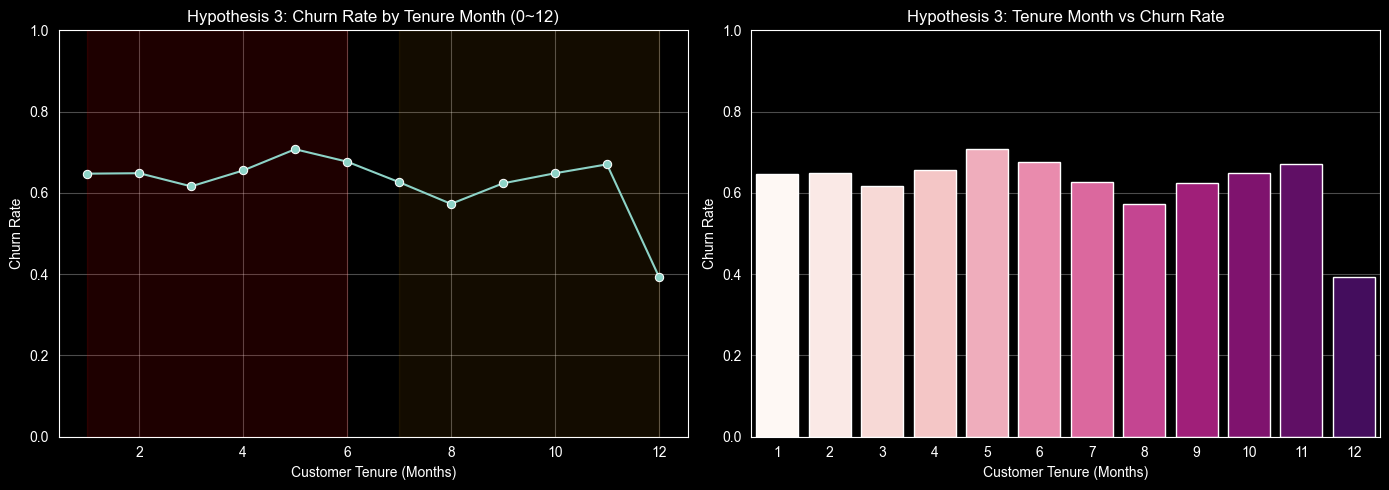

=== [가설 3 + Logistic Regression] ===
Accuracy : 0.7513
Precision: 0.6569
Recall   : 0.3675
F1-Score : 0.4713
F2-Score : 0.4030
AUC      : 0.7612
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      8729
           1       0.66      0.37      0.47      3771

    accuracy                           0.75     12500
   macro avg       0.71      0.64      0.65     12500
weighted avg       0.74      0.75      0.73     12500



C:\Users\monda\anaconda3\envs\dlstudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


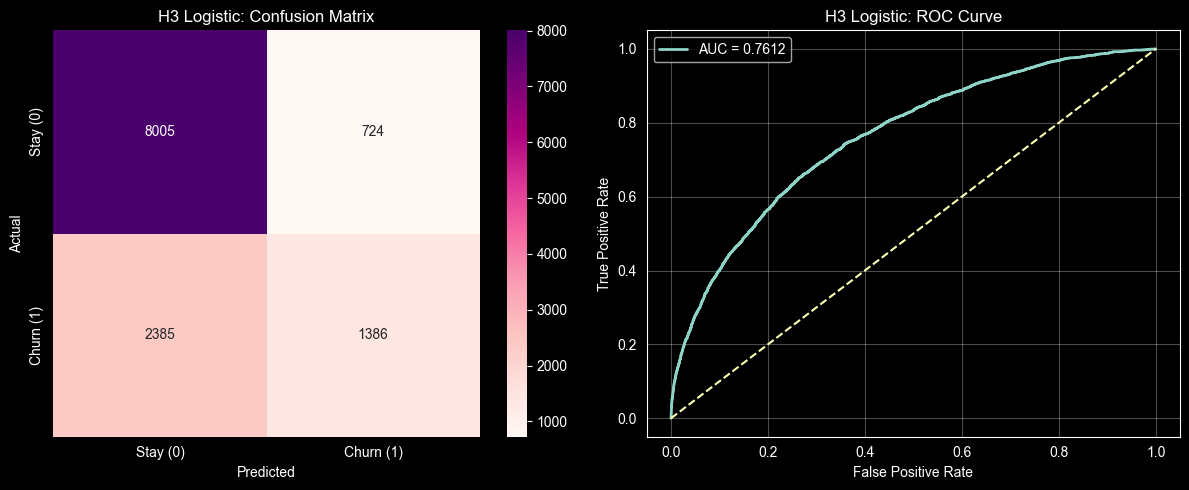

In [25]:
# =========================================================
# [가설 3 + Logistic Regression]
# =========================================================

# 1. 가입월수별 이탈률 시각화
tenure_churn = (
    df.groupby("customer_tenure_months")["churn_flag"]
      .mean()
      .reset_index()
)

early_tenure_churn = tenure_churn[tenure_churn["customer_tenure_months"] <= 12]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=early_tenure_churn,
    x="customer_tenure_months",
    y="churn_flag",
    marker="o"
)
plt.axvspan(1, 6, color="red", alpha=0.12)
plt.axvspan(7, 12, color="orange", alpha=0.08)
plt.title("Hypothesis 3: Churn Rate by Tenure Month (0~12)")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.barplot(
    data=early_tenure_churn,
    x="customer_tenure_months",
    y="churn_flag",
    hue="customer_tenure_months",
    palette="RdPu",
    legend=False
)
plt.title("Hypothesis 3: Tenure Month vs Churn Rate")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 2. 모델용 데이터
feature_cols_h3 = [
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h3].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. 로지스틱 회귀 학습
model_h3_log = LogisticRegression(max_iter=5000)
model_h3_log.fit(X_train, y_train)

# 4. 예측
y_pred = model_h3_log.predict(X_test)
y_probs = model_h3_log.predict_proba(X_test)[:, 1]

# 5. 평가지표
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=2.0)
auc_score = roc_auc_score(y_test, y_probs)

print("=== [가설 3 + Logistic Regression] ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"F2-Score : {f2:.4f}")
print(f"AUC      : {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# 6. 성능 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="RdPu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H3 Logistic: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H3 Logistic: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



 [가설 3 + Logistic Regression + Hyperparameter Tuning]

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\monda\anaconda3\envs\dlstudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\monda\anaconda3\envs\dlstudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _ch

=== [가설 3 + Tuned Logistic Regression] 성능 리포트 ===
최적 파라미터: {'C': 10, 'class_weight': {0: 1, 1: 2}, 'penalty': 'l2', 'solver': 'lbfgs'}
튜닝 후 Accuracy : 0.7119
튜닝 후 Precision: 0.5182
튜닝 후 Recall   : 0.6412
튜닝 후 F1-Score : 0.5732
튜닝 후 F2-Score : 0.6122
튜닝 후 AUC      : 0.7611

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.83      0.74      0.78      8729
           1       0.52      0.64      0.57      3771

    accuracy                           0.71     12500
   macro avg       0.67      0.69      0.68     12500
weighted avg       0.73      0.71      0.72     12500



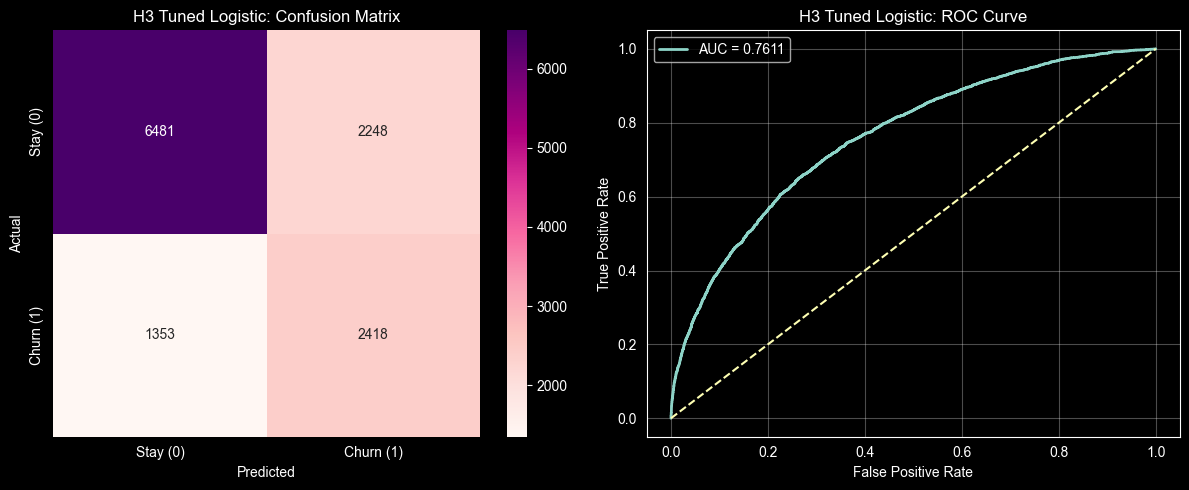

In [5]:
# =========================================================
# [가설 3 + Logistic Regression + Hyperparameter Tuning]
# =========================================================
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score
)

feature_cols_h3 = [
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h3].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

param_grid_log_h3 = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, {0: 1, 1: 2}, {0: 1, 1: 3}]
}

grid_search_h3_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid_log_h3,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_h3_log.fit(X_train, y_train)
best_model_h3_log = grid_search_h3_log.best_estimator_

y_pred_best = best_model_h3_log.predict(X_test)
y_probs_best = best_model_h3_log.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
f2_best = fbeta_score(y_test, y_pred_best, beta=2.0)
auc_best = roc_auc_score(y_test, y_probs_best)

print("=== [가설 3 + Tuned Logistic Regression] 성능 리포트 ===")
print(f"최적 파라미터: {grid_search_h3_log.best_params_}")
print(f"튜닝 후 Accuracy : {acc_best:.4f}")
print(f"튜닝 후 Precision: {precision_best:.4f}")
print(f"튜닝 후 Recall   : {recall_best:.4f}")
print(f"튜닝 후 F1-Score : {f1_best:.4f}")
print(f"튜닝 후 F2-Score : {f2_best:.4f}")
print(f"튜닝 후 AUC      : {auc_best:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="RdPu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H3 Tuned Logistic: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_probs_best)
plt.plot(fpr_best, tpr_best, lw=2, label=f"AUC = {auc_best:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H3 Tuned Logistic: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

가설 3 : 가입 기간이 짧은 신규 고객일수록 초기에 이탈 확률이 높다 + RandomForest


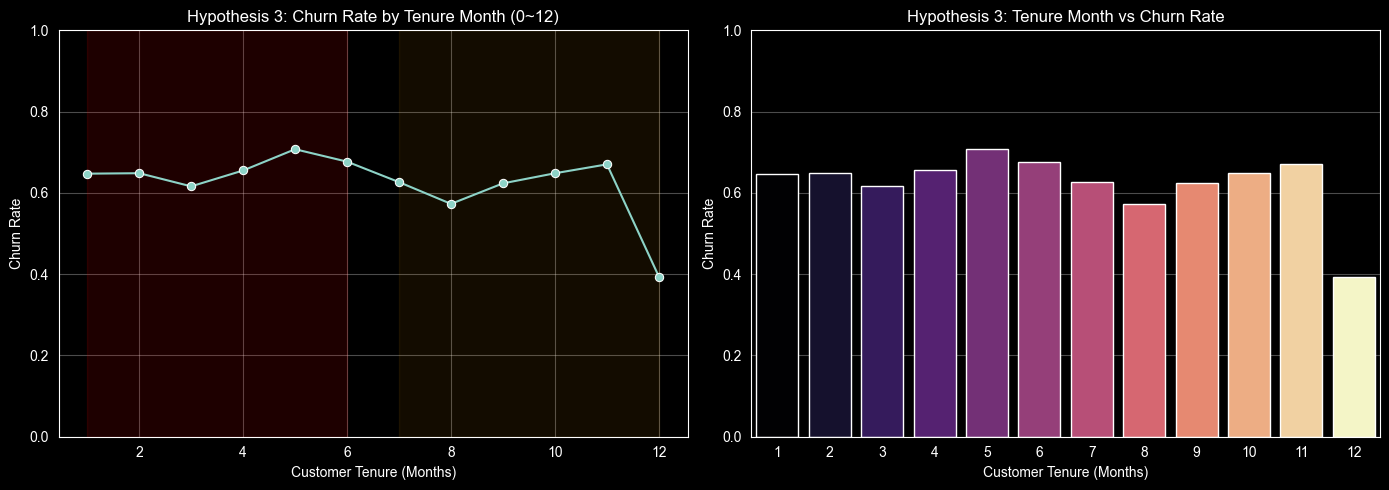

=== [가설 3 + RandomForest] ===
Accuracy : 0.7546
Precision: 0.6495
Recall   : 0.4055
F1-Score : 0.4993
F2-Score : 0.4384
AUC      : 0.7616
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      8729
           1       0.65      0.41      0.50      3771

    accuracy                           0.75     12500
   macro avg       0.71      0.66      0.67     12500
weighted avg       0.74      0.75      0.74     12500



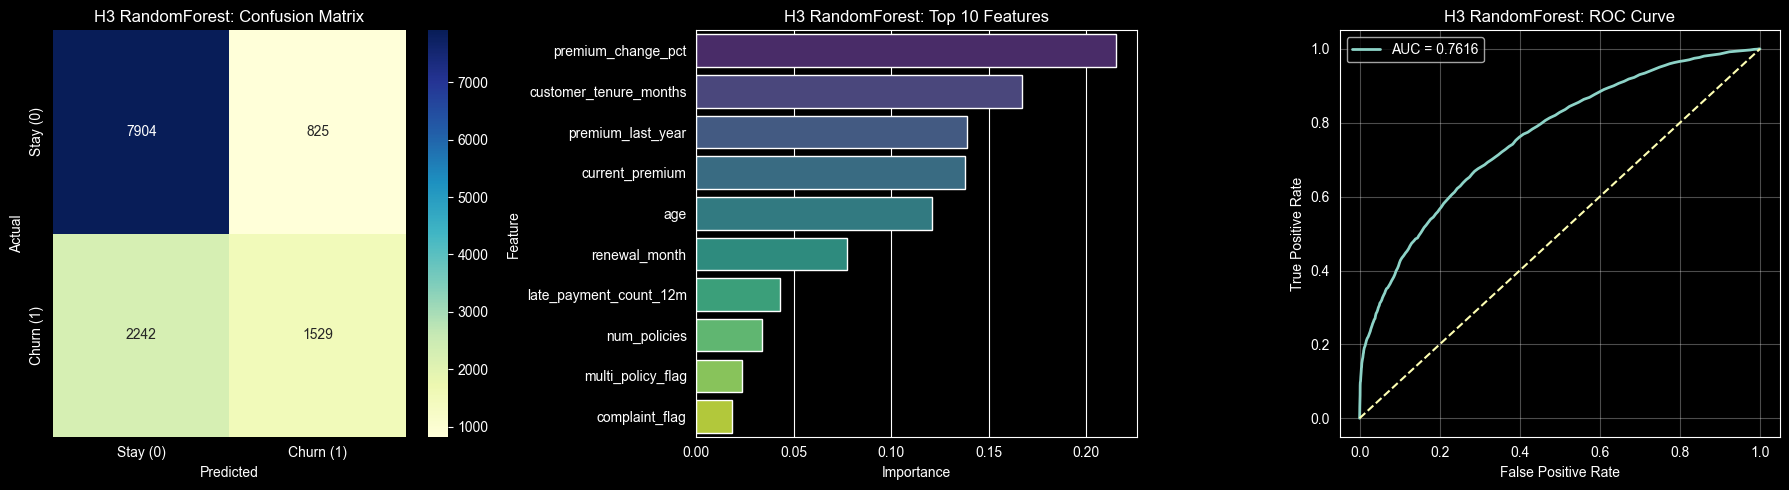

In [6]:
# =========================================================
# [가설 3 + RandomForest]
# =========================================================

# 1. 가입월수별 이탈률 시각화
tenure_churn = (
    df.groupby("customer_tenure_months")["churn_flag"]
      .mean()
      .reset_index()
)

early_tenure_churn = tenure_churn[tenure_churn["customer_tenure_months"] <= 12]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=early_tenure_churn,
    x="customer_tenure_months",
    y="churn_flag",
    marker="o"
)
plt.axvspan(1, 6, color="red", alpha=0.12)
plt.axvspan(7, 12, color="orange", alpha=0.08)
plt.title("Hypothesis 3: Churn Rate by Tenure Month (0~12)")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.barplot(
    data=early_tenure_churn,
    x="customer_tenure_months",
    y="churn_flag",
    hue="customer_tenure_months",
    palette="magma",
    legend=False
)
plt.title("Hypothesis 3: Tenure Month vs Churn Rate")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 2. 모델용 데이터
feature_cols_h3 = [
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h3].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. 랜덤포레스트 학습
model_h3_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model_h3_rf.fit(X_train, y_train)

# 4. 예측
y_pred = model_h3_rf.predict(X_test)
y_probs = model_h3_rf.predict_proba(X_test)[:, 1]

# 5. 평가지표
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=2.0)
auc_score = roc_auc_score(y_test, y_probs)

print("=== [가설 3 + RandomForest] ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"F2-Score : {f2:.4f}")
print(f"AUC      : {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# 6. 성능 시각화
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H3 RandomForest: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_h3_rf.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

sns.barplot(
    data=importances,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("H3 RandomForest: Top 10 Features")

plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H3 RandomForest: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# [가설 3 + RandomForest + Hyperparameter Tuning]

Fitting 3 folds for each of 36 candidates, totalling 108 fits
=== [가설 3 + Tuned RandomForest] 성능 리포트 ===
최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
튜닝 후 Accuracy : 0.6642
튜닝 후 Precision: 0.4661
튜닝 후 Recall   : 0.7759
튜닝 후 F1-Score : 0.5823
튜닝 후 F2-Score : 0.6849
튜닝 후 AUC      : 0.7761

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.86      0.62      0.72      8729
           1       0.47      0.78      0.58      3771

    accuracy                           0.66     12500
   macro avg       0.67      0.70      0.65     12500
weighted avg       0.74      0.66      0.68     12500



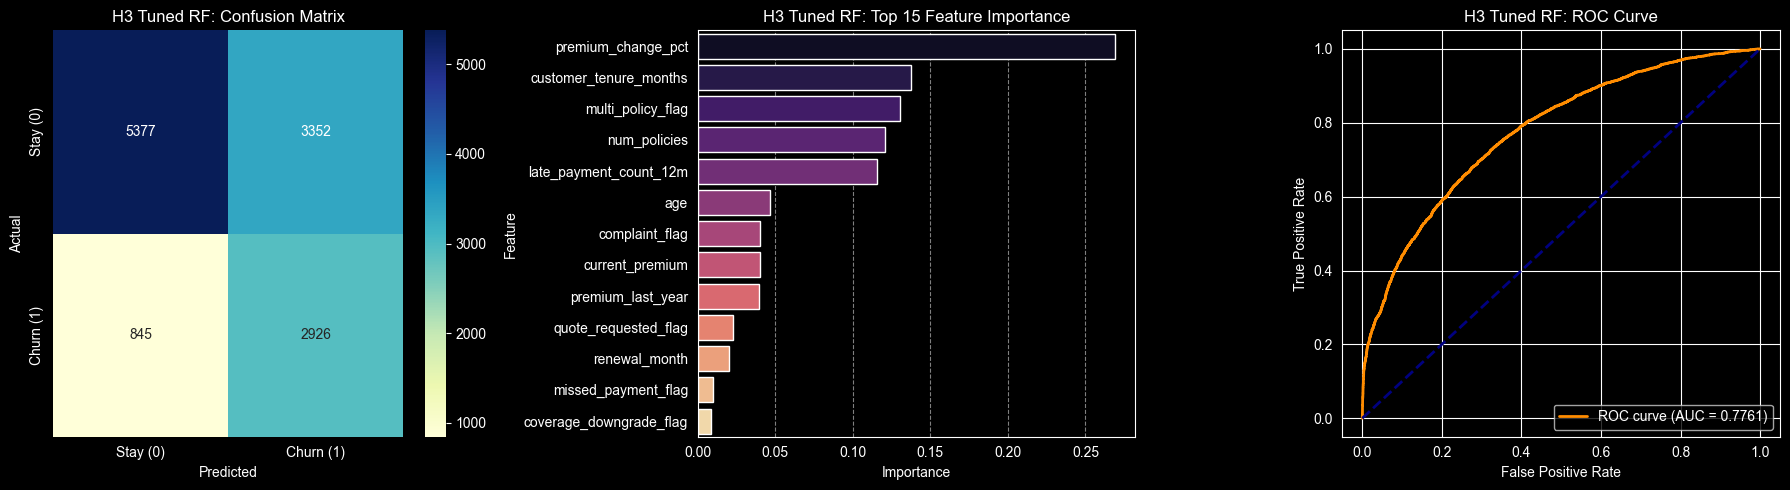

In [7]:
# =========================================================
# [가설 3 + RandomForest + Hyperparameter Tuning]
# =========================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

feature_cols_h3 = [
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h3].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

param_grid_rf_h3 = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search_h3_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight={0: 1, 1: 3},
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf_h3,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_h3_rf.fit(X_train, y_train)
best_model_h3_rf = grid_search_h3_rf.best_estimator_

y_pred_best = best_model_h3_rf.predict(X_test)
y_probs_best = best_model_h3_rf.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
f2_best = fbeta_score(y_test, y_pred_best, beta=2.0)
auc_best = roc_auc_score(y_test, y_probs_best)

print("=== [가설 3 + Tuned RandomForest] 성능 리포트 ===")
print(f"최적 파라미터: {grid_search_h3_rf.best_params_}")
print(f"튜닝 후 Accuracy : {acc_best:.4f}")
print(f"튜닝 후 Precision: {precision_best:.4f}")
print(f"튜닝 후 Recall   : {recall_best:.4f}")
print(f"튜닝 후 F1-Score : {f1_best:.4f}")
print(f"튜닝 후 F2-Score : {f2_best:.4f}")
print(f"튜닝 후 AUC      : {auc_best:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H3 Tuned RF: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
importances_best = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model_h3_rf.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

sns.barplot(
    data=importances_best,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)
plt.title("H3 Tuned RF: Top 15 Feature Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.subplot(1, 3, 3)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_probs_best)
plt.plot(fpr_best, tpr_best, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {auc_best:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("H3 Tuned RF: ROC Curve")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# 가설 3 + XGBoost
# =========================================================

feature_cols_h3 = [
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h3]
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model_h3_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model_h3_xgb.fit(X_train, y_train)

y_pred = model_h3_xgb.predict(X_test)
y_probs = model_h3_xgb.predict_proba(X_test)[:,1]

print("=== 가설3 + XGBoost ===")

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("F2 Score :", fbeta_score(y_test,y_pred,beta=2))
print("AUC      :", roc_auc_score(y_test,y_probs))

print(classification_report(y_test,y_pred))

=== 가설3 + XGBoost ===
Accuracy : 0.76328
Precision: 0.6869244935543278
Recall   : 0.3956510209493503
F1 Score : 0.5021033148241629
F2 Score : 0.4323133982382939
AUC      : 0.7807602586853218
              precision    recall  f1-score   support

           0       0.78      0.92      0.84      8729
           1       0.69      0.40      0.50      3771

    accuracy                           0.76     12500
   macro avg       0.73      0.66      0.67     12500
weighted avg       0.75      0.76      0.74     12500



In [9]:
# =========================================================
# 가설 3 + XGBoost + GridSearch
# =========================================================


from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}

grid_xgb_h3 = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_xgb_h3.fit(X_train,y_train)

best_model_h3_xgb = grid_xgb_h3.best_estimator_

y_pred = best_model_h3_xgb.predict(X_test)
y_probs = best_model_h3_xgb.predict_proba(X_test)[:,1]

print("=== 가설3 + Tuned XGBoost ===")

print("Best Params:",grid_xgb_h3.best_params_)
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("F2 Score :", fbeta_score(y_test,y_pred,beta=2))
print("AUC      :", roc_auc_score(y_test,y_probs))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
=== 가설3 + Tuned XGBoost ===
Best Params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Accuracy : 0.76408
Precision: 0.6883593033913841
Recall   : 0.3983028374436489
F1 Score : 0.5046195195699648
F2 Score : 0.43495887872118616
AUC      : 0.7801558456361486


In [10]:
# ------------------------------------------------------------------------------------------------#

가설 4 고객센터 문의 횟수가 많을수록 잠재적 불만족 상태이며 이탈 징후를 보인다 + Logistic Regression

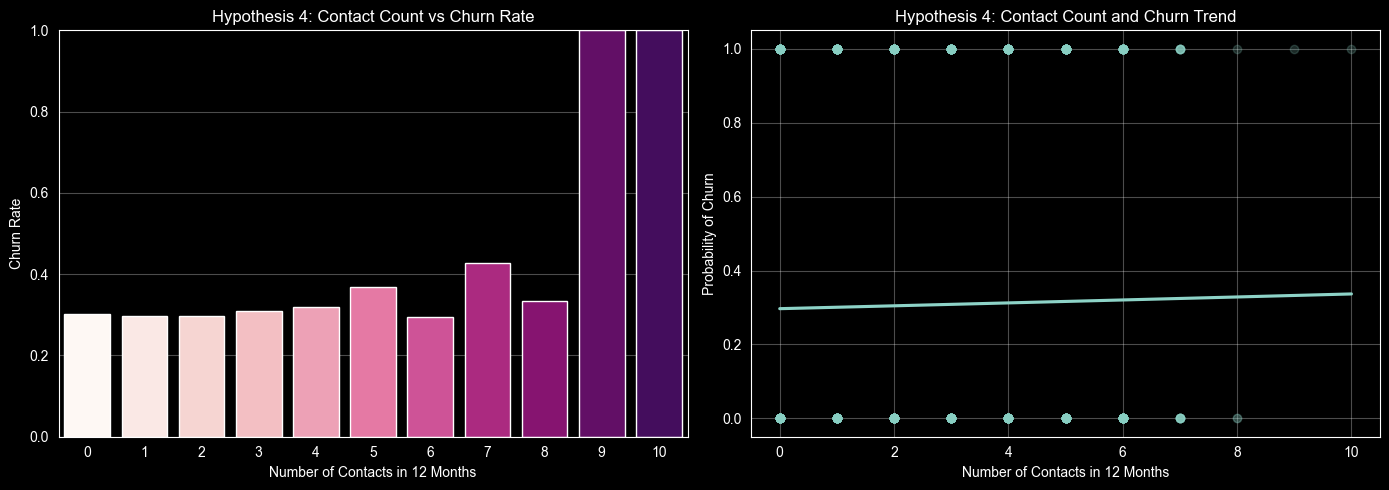

C:\Users\monda\anaconda3\envs\dlstudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== [가설 4 + Logistic Regression] ===
Accuracy : 0.7510
Precision: 0.6546
Recall   : 0.3694
F1-Score : 0.4723
F2-Score : 0.4047
AUC      : 0.7614
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      8729
           1       0.65      0.37      0.47      3771

    accuracy                           0.75     12500
   macro avg       0.71      0.64      0.65     12500
weighted avg       0.74      0.75      0.73     12500



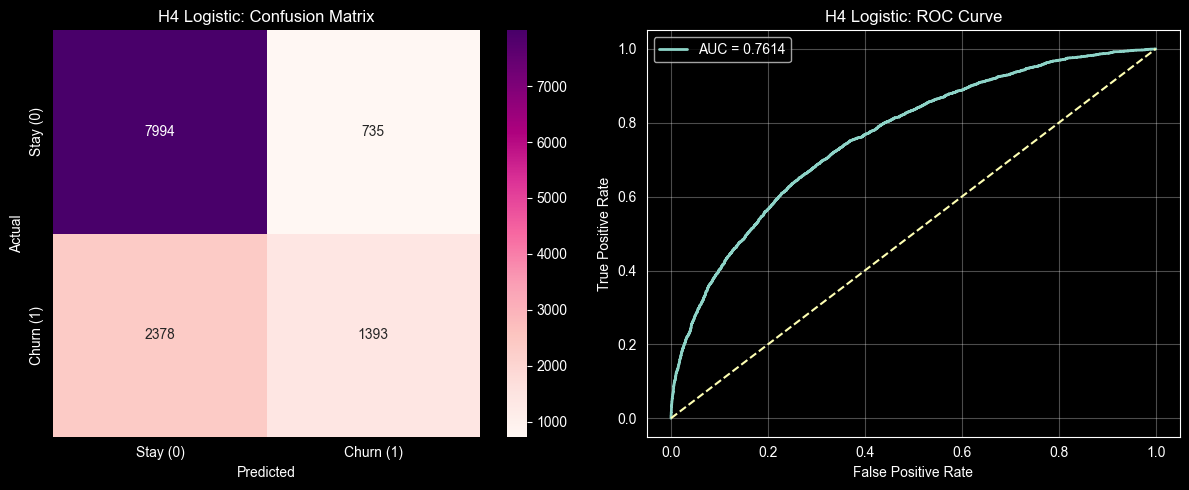

In [11]:
# =========================================================
# [가설 4 + Logistic Regression]
# =========================================================

# 1. 문의횟수별 이탈률 시각화
contact_churn = (
    df.groupby("num_contacts_12m")["churn_flag"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    data=contact_churn,
    x="num_contacts_12m",
    y="churn_flag",
    hue="num_contacts_12m",
    palette="RdPu",
    legend=False
)
plt.title("Hypothesis 4: Contact Count vs Churn Rate")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
sns.regplot(
    data=df,
    x="num_contacts_12m",
    y="churn_flag",
    logistic=True,
    ci=None,
    scatter_kws={"alpha": 0.2}
)
plt.title("Hypothesis 4: Contact Count and Churn Trend")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Probability of Churn")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. 모델용 데이터
feature_cols_h4 = [
    "num_contacts_12m",
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h4].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. 로지스틱 회귀
model_h4_log = LogisticRegression(max_iter=5000)
model_h4_log.fit(X_train, y_train)

# 4. 예측
y_pred = model_h4_log.predict(X_test)
y_probs = model_h4_log.predict_proba(X_test)[:, 1]

# 5. 평가지표
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=2.0)
auc_score = roc_auc_score(y_test, y_probs)

print("=== [가설 4 + Logistic Regression] ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"F2-Score : {f2:.4f}")
print(f"AUC      : {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# 6. 성능 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="RdPu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H4 Logistic: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H4 Logistic: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[가설 4 + Logistic Regression + Hyperparameter Tuning]

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\monda\anaconda3\envs\dlstudy_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== [가설 4 + Tuned Logistic Regression] 성능 리포트 ===
최적 파라미터: {'C': 10, 'class_weight': {0: 1, 1: 2}, 'penalty': 'l2', 'solver': 'liblinear'}
튜닝 후 Accuracy : 0.7124
튜닝 후 Precision: 0.5189
튜닝 후 Recall   : 0.6412
튜닝 후 F1-Score : 0.5736
튜닝 후 F2-Score : 0.6123
튜닝 후 AUC      : 0.7612

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.83      0.74      0.78      8729
           1       0.52      0.64      0.57      3771

    accuracy                           0.71     12500
   macro avg       0.67      0.69      0.68     12500
weighted avg       0.73      0.71      0.72     12500



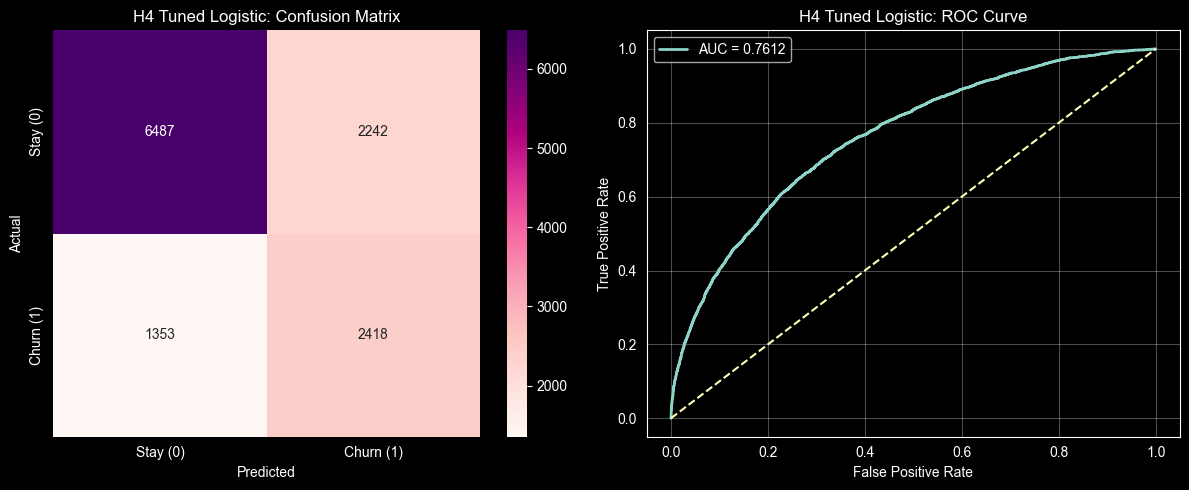

In [12]:
# =========================================================
# [가설 4 + Logistic Regression + Hyperparameter Tuning]
# =========================================================

feature_cols_h4 = [
    "num_contacts_12m",
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h4].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

param_grid_log_h4 = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, {0: 1, 1: 2}, {0: 1, 1: 3}]
}

grid_search_h4_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid_log_h4,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_h4_log.fit(X_train, y_train)
best_model_h4_log = grid_search_h4_log.best_estimator_

y_pred_best = best_model_h4_log.predict(X_test)
y_probs_best = best_model_h4_log.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
f2_best = fbeta_score(y_test, y_pred_best, beta=2.0)
auc_best = roc_auc_score(y_test, y_probs_best)

print("=== [가설 4 + Tuned Logistic Regression] 성능 리포트 ===")
print(f"최적 파라미터: {grid_search_h4_log.best_params_}")
print(f"튜닝 후 Accuracy : {acc_best:.4f}")
print(f"튜닝 후 Precision: {precision_best:.4f}")
print(f"튜닝 후 Recall   : {recall_best:.4f}")
print(f"튜닝 후 F1-Score : {f1_best:.4f}")
print(f"튜닝 후 F2-Score : {f2_best:.4f}")
print(f"튜닝 후 AUC      : {auc_best:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="RdPu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H4 Tuned Logistic: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_probs_best)
plt.plot(fpr_best, tpr_best, lw=2, label=f"AUC = {auc_best:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H4 Tuned Logistic: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

가설 4 고객센터 문의 횟수가 많을수록 잠재적 불만족 상태이며 이탈 징후를 보인다 + RandomForest

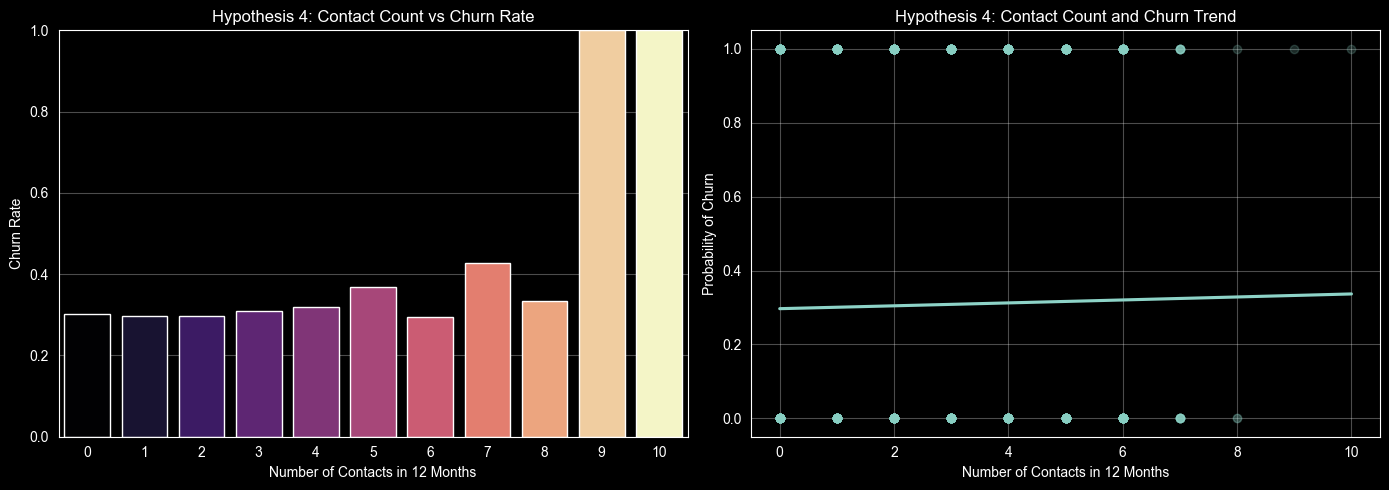

=== [가설 4 + RandomForest] ===
Accuracy : 0.7572
Precision: 0.6597
Recall   : 0.4031
F1-Score : 0.5004
F2-Score : 0.4371
AUC      : 0.7641
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      8729
           1       0.66      0.40      0.50      3771

    accuracy                           0.76     12500
   macro avg       0.72      0.66      0.67     12500
weighted avg       0.74      0.76      0.74     12500



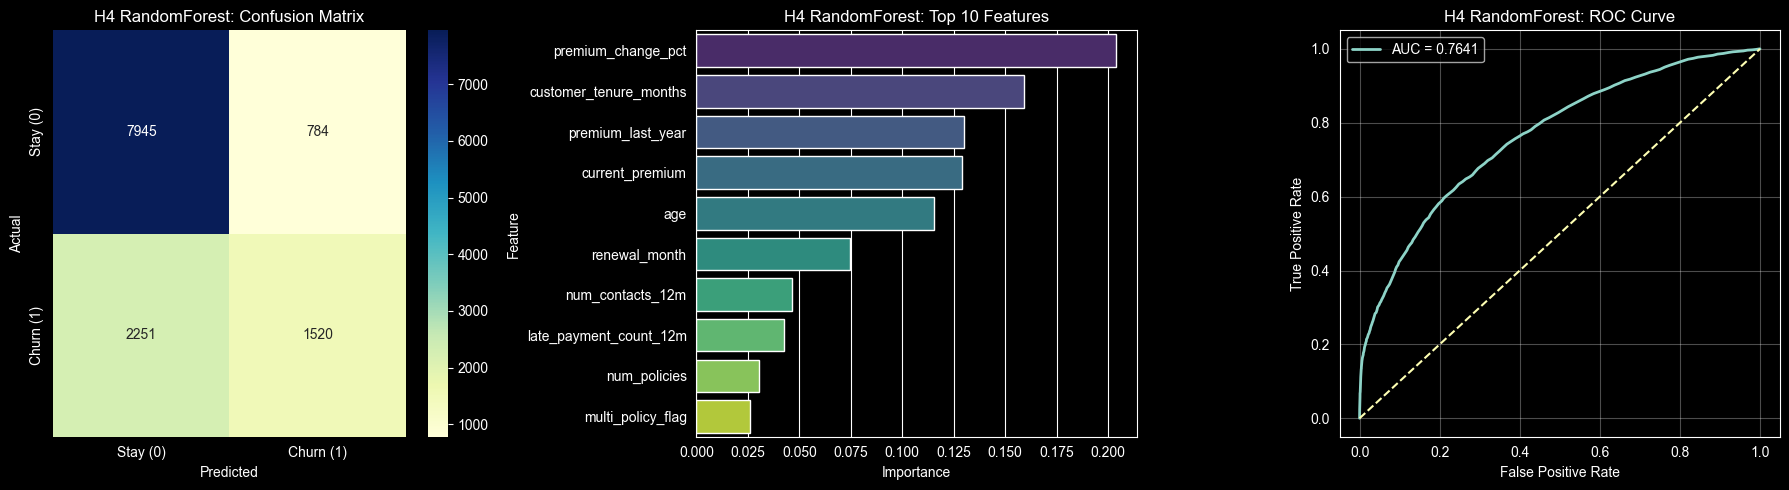

In [13]:
# =========================================================
# [가설 4 + RandomForest]
# =========================================================

# 1. 문의횟수별 이탈률 시각화
contact_churn = (
    df.groupby("num_contacts_12m")["churn_flag"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    data=contact_churn,
    x="num_contacts_12m",
    y="churn_flag",
    hue="num_contacts_12m",
    palette="magma",
    legend=False
)
plt.title("Hypothesis 4: Contact Count vs Churn Rate")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Churn Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
sns.regplot(
    data=df,
    x="num_contacts_12m",
    y="churn_flag",
    logistic=True,
    ci=None,
    scatter_kws={"alpha": 0.2}
)
plt.title("Hypothesis 4: Contact Count and Churn Trend")
plt.xlabel("Number of Contacts in 12 Months")
plt.ylabel("Probability of Churn")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. 모델용 데이터
feature_cols_h4 = [
    "num_contacts_12m",
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h4].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# 3. 랜덤포레스트
model_h4_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model_h4_rf.fit(X_train, y_train)

# 4. 예측
y_pred = model_h4_rf.predict(X_test)
y_probs = model_h4_rf.predict_proba(X_test)[:, 1]

# 5. 평가지표
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = fbeta_score(y_test, y_pred, beta=2.0)
auc_score = roc_auc_score(y_test, y_probs)

print("=== [가설 4 + RandomForest] ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"F2-Score : {f2:.4f}")
print(f"AUC      : {auc_score:.4f}")
print(classification_report(y_test, y_pred))

# 6. 성능 시각화
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H4 RandomForest: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_h4_rf.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

sns.barplot(
    data=importances,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("H4 RandomForest: Top 10 Features")

plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.title("H4 RandomForest: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[가설 4 + RandomForest + Hyperparameter Tuning]

Fitting 3 folds for each of 36 candidates, totalling 108 fits
=== [가설 4 + Tuned RandomForest] 성능 리포트 ===
최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
튜닝 후 Accuracy : 0.6623
튜닝 후 Precision: 0.4646
튜닝 후 Recall   : 0.7836
튜닝 후 F1-Score : 0.5834
튜닝 후 F2-Score : 0.6890
튜닝 후 AUC      : 0.7757

[상세 분류 리포트]
              precision    recall  f1-score   support

           0       0.87      0.61      0.72      8729
           1       0.46      0.78      0.58      3771

    accuracy                           0.66     12500
   macro avg       0.67      0.70      0.65     12500
weighted avg       0.75      0.66      0.68     12500



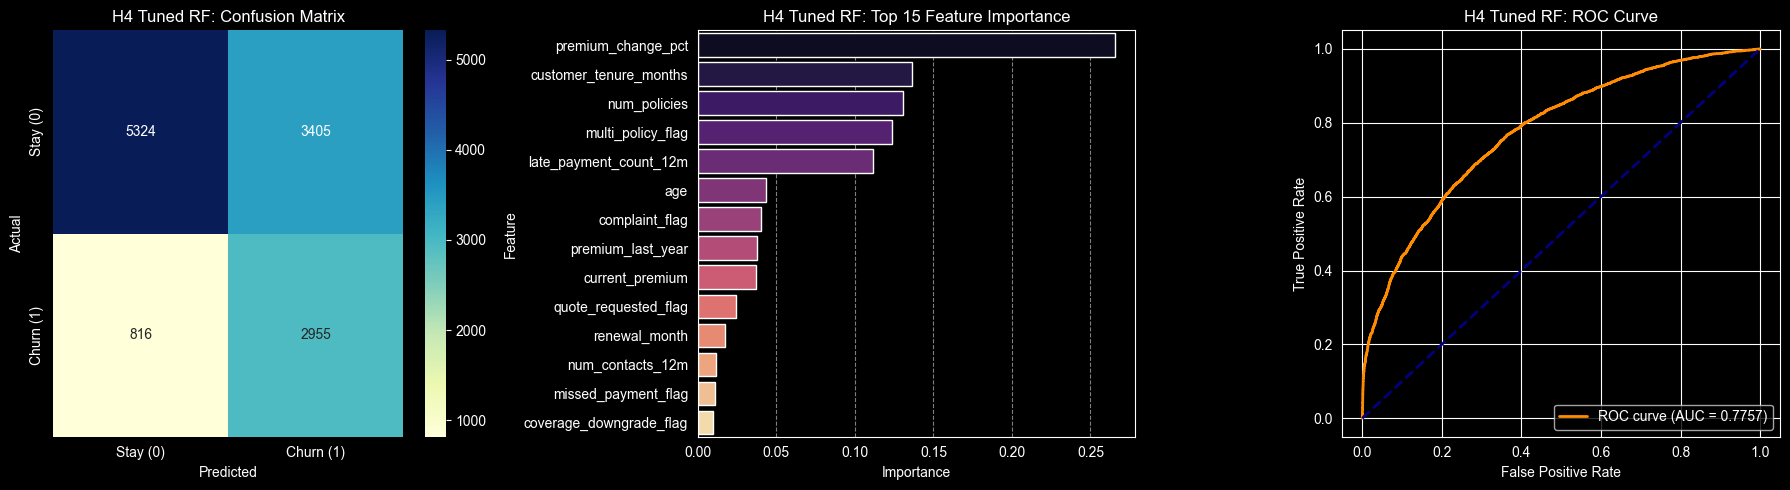

In [14]:
# =========================================================
# [가설 4 + RandomForest + Hyperparameter Tuning]
# =========================================================

feature_cols_h4 = [
    "num_contacts_12m",
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h4].copy()
y = df["churn_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

param_grid_rf_h4 = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search_h4_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight={0: 1, 1: 3},
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf_h4,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_h4_rf.fit(X_train, y_train)
best_model_h4_rf = grid_search_h4_rf.best_estimator_

y_pred_best = best_model_h4_rf.predict(X_test)
y_probs_best = best_model_h4_rf.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
f2_best = fbeta_score(y_test, y_pred_best, beta=2.0)
auc_best = roc_auc_score(y_test, y_probs_best)

print("=== [가설 4 + Tuned RandomForest] 성능 리포트 ===")
print(f"최적 파라미터: {grid_search_h4_rf.best_params_}")
print(f"튜닝 후 Accuracy : {acc_best:.4f}")
print(f"튜닝 후 Precision: {precision_best:.4f}")
print(f"튜닝 후 Recall   : {recall_best:.4f}")
print(f"튜닝 후 F1-Score : {f1_best:.4f}")
print(f"튜닝 후 F2-Score : {f2_best:.4f}")
print(f"튜닝 후 AUC      : {auc_best:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"]
)
plt.title("H4 Tuned RF: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
importances_best = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model_h4_rf.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

sns.barplot(
    data=importances_best,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)
plt.title("H4 Tuned RF: Top 15 Feature Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.subplot(1, 3, 3)
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_probs_best)
plt.plot(fpr_best, tpr_best, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {auc_best:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("H4 Tuned RF: ROC Curve")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [15]:
# =========================================================
# 가설 4 + XGBoost
# =========================================================

feature_cols_h4 = [
    "num_contacts_12m",
    "customer_tenure_months",
    "age",
    "num_policies",
    "multi_policy_flag",
    "current_premium",
    "premium_change_pct",
    "premium_last_year",
    "late_payment_count_12m",
    "missed_payment_flag",
    "complaint_flag",
    "quote_requested_flag",
    "coverage_downgrade_flag",
    "renewal_month"
]

X = df[feature_cols_h4]
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model_h4_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model_h4_xgb.fit(X_train,y_train)

y_pred = model_h4_xgb.predict(X_test)
y_probs = model_h4_xgb.predict_proba(X_test)[:,1]

print("=== 가설4 + XGBoost ===")

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("F2 Score :", fbeta_score(y_test,y_pred,beta=2))
print("AUC      :", roc_auc_score(y_test,y_probs))

print(classification_report(y_test,y_pred))

=== 가설4 + XGBoost ===
Accuracy : 0.76472
Precision: 0.6926648096564532
Recall   : 0.3956510209493503
F1 Score : 0.5036286919831223
F2 Score : 0.4327648219050934
AUC      : 0.7814370506186473
              precision    recall  f1-score   support

           0       0.78      0.92      0.85      8729
           1       0.69      0.40      0.50      3771

    accuracy                           0.76     12500
   macro avg       0.74      0.66      0.67     12500
weighted avg       0.75      0.76      0.74     12500



In [16]:
# =========================================================
# 가설 4 + XGBoost + GridSearch
# =========================================================


grid_xgb_h4 = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_xgb_h4.fit(X_train,y_train)

best_model_h4_xgb = grid_xgb_h4.best_estimator_

y_pred = best_model_h4_xgb.predict(X_test)
y_probs = best_model_h4_xgb.predict_proba(X_test)[:,1]

print("=== 가설4 + Tuned XGBoost ===")

print("Best Params:",grid_xgb_h4.best_params_)
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))
print("F2 Score :", fbeta_score(y_test,y_pred,beta=2))
print("AUC      :", roc_auc_score(y_test,y_probs))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
=== 가설4 + Tuned XGBoost ===
Best Params: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Accuracy : 0.76552
Precision: 0.6917808219178082
Recall   : 0.4017501988862371
F1 Score : 0.5083039758429794
F2 Score : 0.43852031955540116
AUC      : 0.7812295898002309
